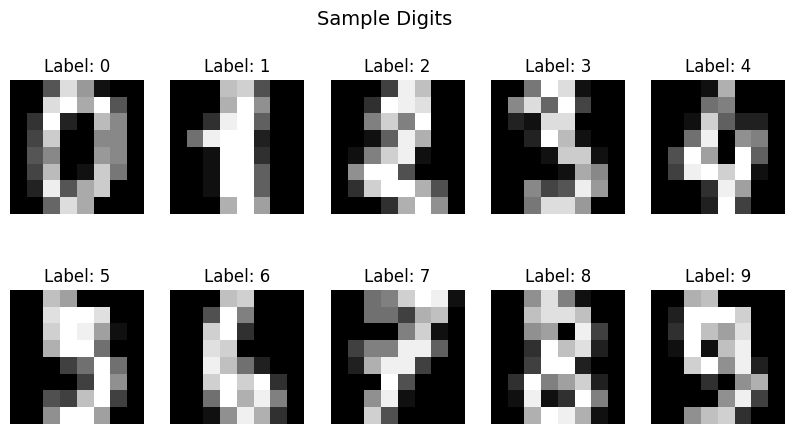

/tmp/ipython-input-555529805.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


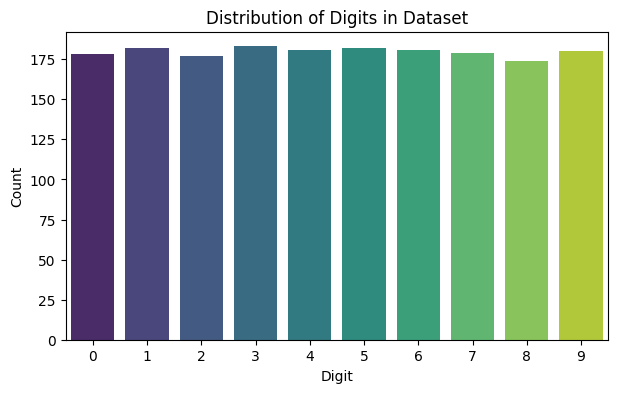

✅ Accuracy: 97.50%


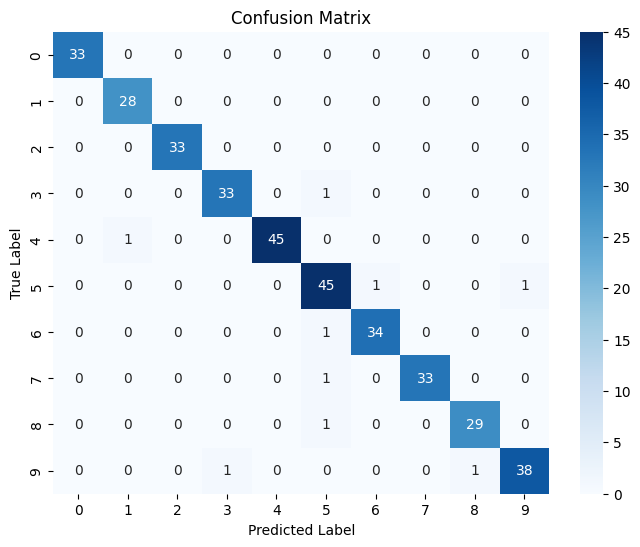


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


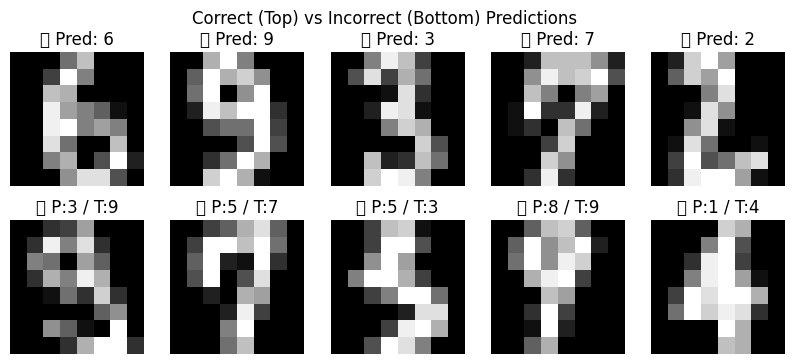

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# 2️⃣ Show some sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.suptitle("Sample Digits", fontsize=14)
plt.show()

# 3️⃣ Histogram of labels
plt.figure(figsize=(7, 4))
sns.countplot(x=y, palette="viridis")
plt.title("Distribution of Digits in Dataset")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# 4️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Train simple classifier
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# 6️⃣ Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc*100:.2f}%")

# 7️⃣ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 8️⃣ Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 9️⃣ Correct vs Incorrect Predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
correct = np.where(y_pred == y_test)[0]
incorrect = np.where(y_pred != y_test)[0]

for i, ax in enumerate(axes.flatten()):
    if i < 5:
        idx = correct[i]
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"✅ Pred: {y_pred[idx]}")
    else:
        idx = incorrect[i - 5]
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"❌ P:{y_pred[idx]} / T:{y_test[idx]}")
    ax.axis("off")

plt.suptitle("Correct (Top) vs Incorrect (Bottom) Predictions", fontsize=12)
plt.show()
